# AI-Based Real-Time Anomaly Detection and Autonomous Decision Support System for Deep Space Missions

## Dataset
**NASA CMAPSS Turbofan Engine Degradation Simulation Dataset**

🔗 **Kaggle Link:** https://www.kaggle.com/datasets/behrad3d/nasa-cmaps

---
### Project Phases
- **Phase 1** – EDA, Feature Engineering
- **Phase 2** – Statistical Baseline, Isolation Forest, One-Class SVM, PyTorch Autoencoder, PyTorch LSTM, RUL Prediction, Model Evaluation
- **Phase 3** – Autonomous Decision Layer (Rule-based + AI Risk Scoring + Decision Confidence)
- **Phase 4** – Visualization Dashboard

## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, confusion_matrix,
    classification_report, f1_score
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import plotly.graph_objects as go
from plotly.subplots import make_subplots

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device : {DEVICE}")
print(f"PyTorch      : {torch.__version__}")

Using device : cpu
PyTorch      : 2.10.0+cpu


---
## Phase 1: Foundations — Data Loading & EDA
### 1.1 Load Dataset

In [2]:
col_names = ['unit_id', 'cycle', 'op_set_1', 'op_set_2', 'op_set_3'] + \
            [f'sensor_{i}' for i in range(1, 22)]

train_df = pd.read_csv('train_FD001.txt', sep=r'\s+', header=None, names=col_names)
test_df  = pd.read_csv('test_FD001.txt',  sep=r'\s+', header=None, names=col_names)
rul_df   = pd.read_csv('RUL_FD001.txt',   sep=r'\s+', header=None, names=['RUL'])

print(f"Train : {train_df.shape}  |  Test : {test_df.shape}  |  RUL : {rul_df.shape}")
train_df.head()

Train : (20631, 26)  |  Test : (13096, 26)  |  RUL : (100, 1)


,unit_id,cycle,op_set_1,op_set_2,op_set_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


### 1.2 Add RUL & Failure Labels

In [3]:
FAILURE_THRESHOLD = 30

max_cycles = train_df.groupby('unit_id')['cycle'].max().reset_index()
max_cycles.columns = ['unit_id', 'max_cycle']
train_df = train_df.merge(max_cycles, on='unit_id')
train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']
train_df.drop('max_cycle', axis=1, inplace=True)
train_df['failure_label'] = (train_df['RUL'] <= FAILURE_THRESHOLD).astype(int)

print(f"RUL range: {train_df['RUL'].min()} to {train_df['RUL'].max()}")
print(train_df['failure_label'].value_counts().rename({0: 'Normal', 1: 'Near-Failure'}))

RUL range: 0 to 361
failure_label
Normal          17531
Near-Failure     3100
Name: count, dtype: int64


### 1.3 Exploratory Data Analysis

In [4]:
print("Missing values:", train_df.isnull().sum().sum())
train_df.describe()

Missing values: 0


,unit_id,cycle,op_set_1,op_set_2,op_set_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL,failure_label
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705,107.807862,0.150259
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,5.329200e-15,...,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251,68.880990,0.357334
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200,0.000000,0.000000
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800,51.000000,0.000000
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900,103.000000,0.000000
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800,155.000000,0.000000
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400,361.000000,1.000000


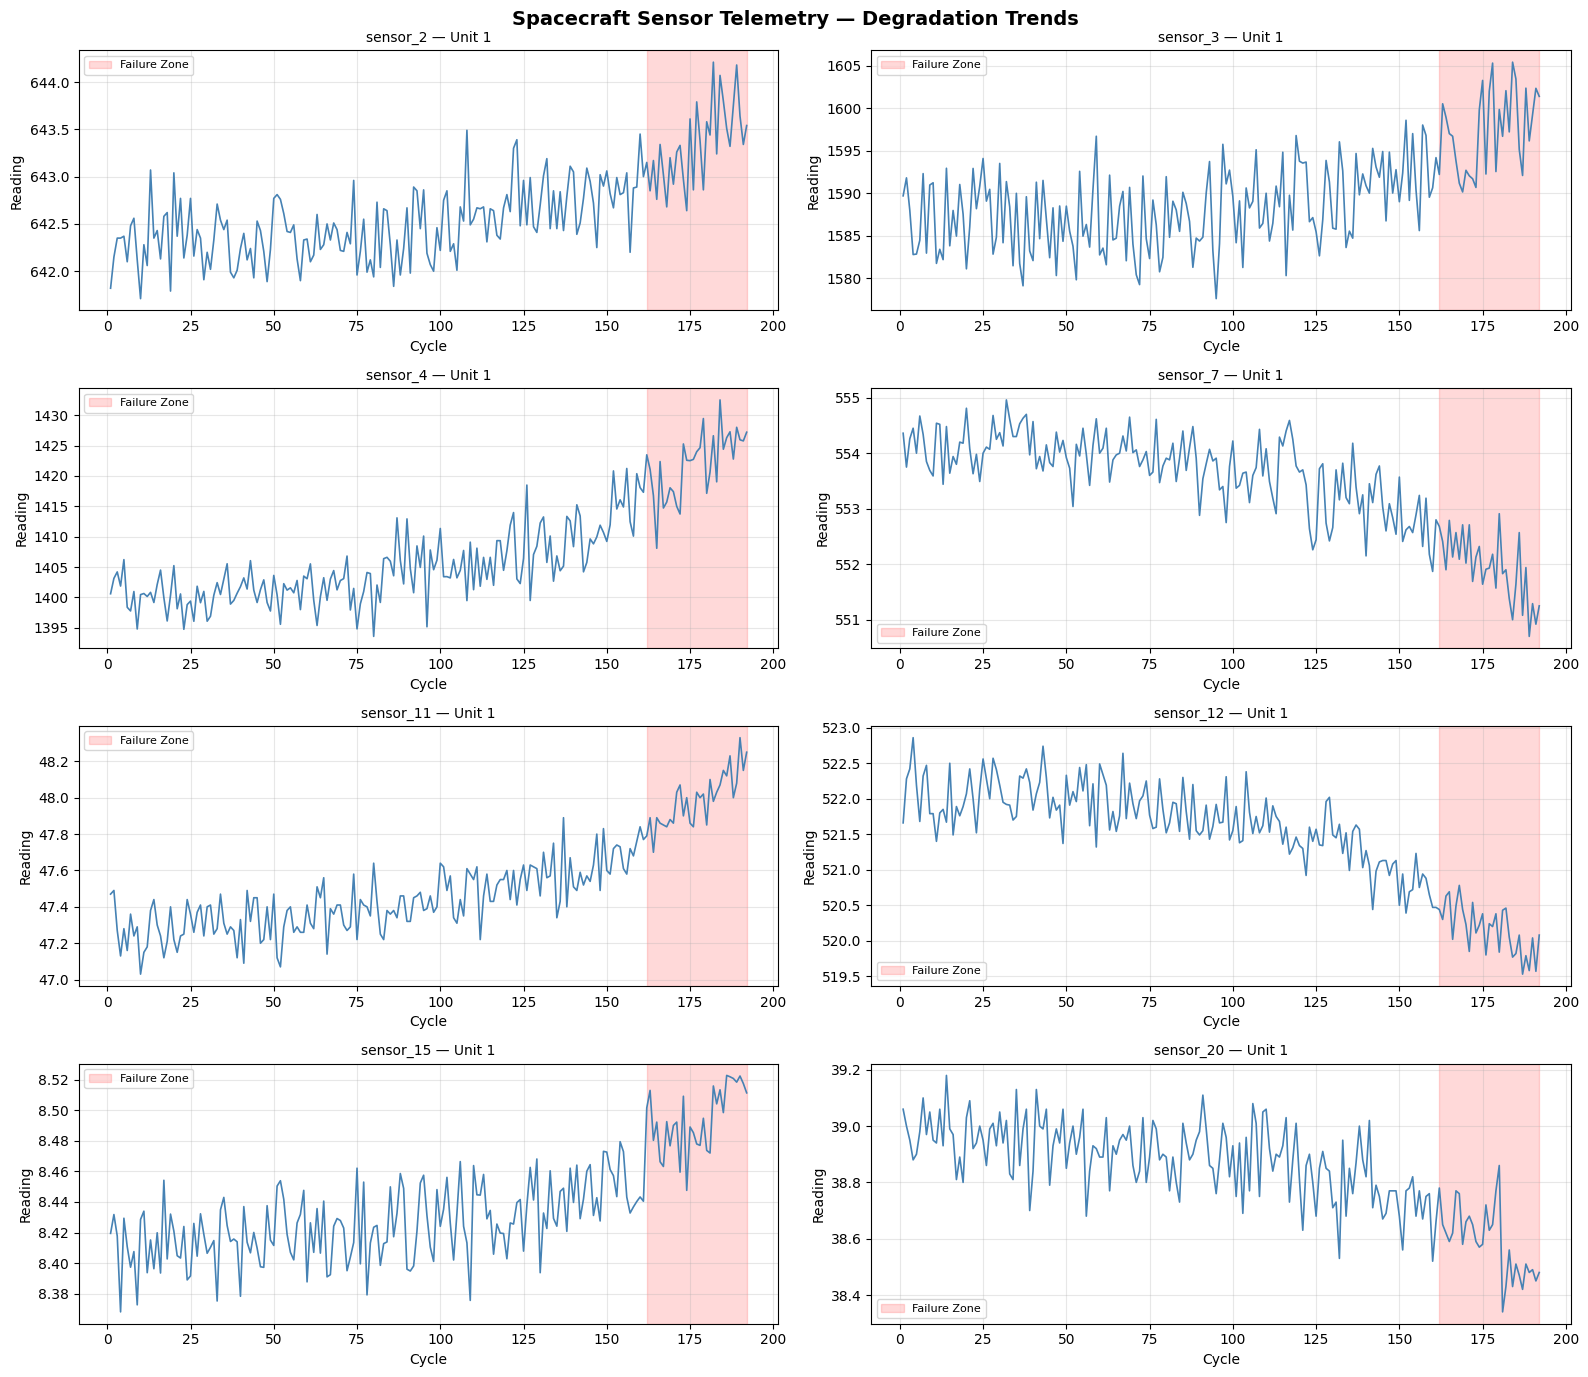

In [5]:
# Sensor degradation trends for Unit 1
unit1 = train_df[train_df['unit_id'] == 1]
key_sensors = ['sensor_2','sensor_3','sensor_4','sensor_7',
               'sensor_11','sensor_12','sensor_15','sensor_20']

fig, axes = plt.subplots(4, 2, figsize=(16, 14))
axes = axes.flatten()
fail_start = unit1['cycle'].max() - FAILURE_THRESHOLD
for i, sensor in enumerate(key_sensors):
    axes[i].plot(unit1['cycle'], unit1[sensor], color='steelblue', linewidth=1.2)
    axes[i].axvspan(fail_start, unit1['cycle'].max(), alpha=0.15, color='red', label='Failure Zone')
    axes[i].set_title(f'{sensor} — Unit 1', fontsize=10)
    axes[i].set_xlabel('Cycle')
    axes[i].set_ylabel('Reading')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)
plt.suptitle('Spacecraft Sensor Telemetry — Degradation Trends', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sensor_trends.png', dpi=150, bbox_inches='tight')
plt.show()

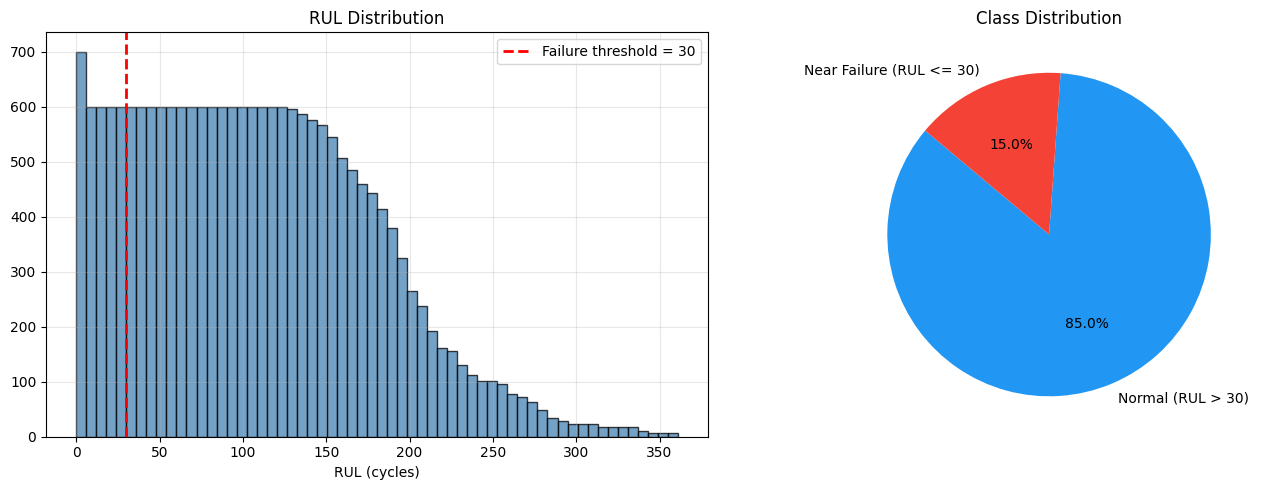

In [6]:
# RUL distribution + class balance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(train_df['RUL'], bins=60, color='steelblue', edgecolor='black', alpha=0.75)
axes[0].axvline(FAILURE_THRESHOLD, color='red', linestyle='--', linewidth=2,
                label=f'Failure threshold = {FAILURE_THRESHOLD}')
axes[0].set_title('RUL Distribution')
axes[0].set_xlabel('RUL (cycles)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].pie(train_df['failure_label'].value_counts(),
            labels=['Normal (RUL > 30)', 'Near Failure (RUL <= 30)'],
            autopct='%1.1f%%', colors=['#2196F3', '#F44336'], startangle=140)
axes[1].set_title('Class Distribution')
plt.tight_layout()
plt.savefig('rul_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

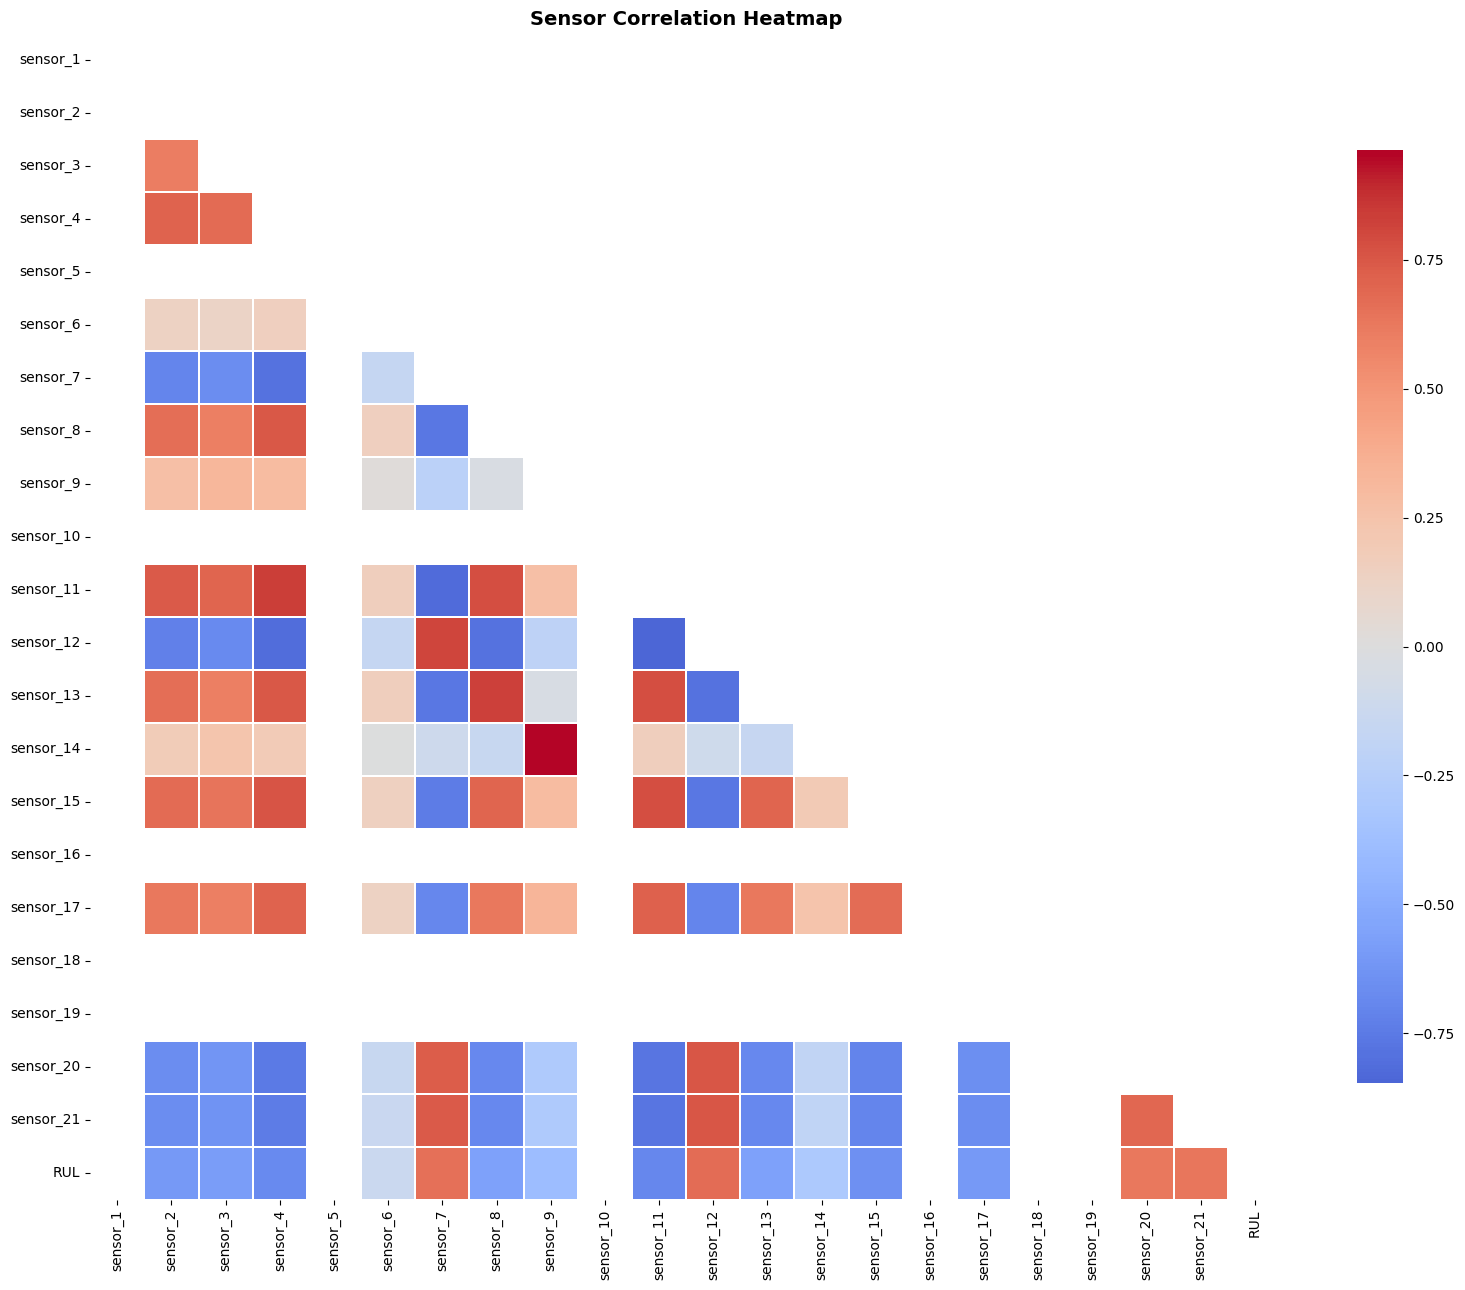

In [7]:
# Correlation heatmap
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
corr = train_df[sensor_cols + ['RUL']].corr()
plt.figure(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', center=0,
            linewidths=0.3, cbar_kws={'shrink': 0.8})
plt.title('Sensor Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.4 Feature Engineering

In [8]:
# Drop near-zero variance sensors
sensor_std   = train_df[sensor_cols].std()
flat_sensors = sensor_std[sensor_std < 0.01].index.tolist()
useful_sensors = [s for s in sensor_cols if s not in flat_sensors]
print(f"Dropped : {flat_sensors}")
print(f"Kept    : {len(useful_sensors)} sensors")

Dropped : ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Kept    : 14 sensors


In [9]:
def add_rolling_features(df, sensors, windows=[5, 10]):
    df = df.copy()
    for s in sensors:
        for w in windows:
            df[f'{s}_rmean{w}'] = df.groupby('unit_id')[s].transform(
                lambda x: x.rolling(w, min_periods=1).mean())
            df[f'{s}_rstd{w}']  = df.groupby('unit_id')[s].transform(
                lambda x: x.rolling(w, min_periods=1).std().fillna(0))
    return df

train_df = add_rolling_features(train_df, useful_sensors)
test_df  = add_rolling_features(test_df,  useful_sensors)

train_df['cycle_norm'] = train_df['cycle'] / train_df.groupby('unit_id')['cycle'].transform('max')
test_df['cycle_norm']  = test_df['cycle']  / test_df.groupby('unit_id')['cycle'].transform('max')

print(f"Training columns: {train_df.shape[1]}")

Training columns: 85


---
## Phase 2: Model Development
### 2.1 Prepare Feature Matrix

In [10]:
feature_cols = (useful_sensors +
                [f'{s}_rmean5' for s in useful_sensors] +
                [f'{s}_rstd5'  for s in useful_sensors] +
                ['op_set_1', 'op_set_2', 'op_set_3', 'cycle_norm'])

X_train = train_df[feature_cols].values
y_train = train_df['failure_label'].values

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Test: last cycle per engine (standard CMAPSS evaluation)
last_test     = test_df.groupby('unit_id').last().reset_index()
X_test_scaled = scaler.transform(last_test[feature_cols].values)
y_test        = (rul_df['RUL'].values <= FAILURE_THRESHOLD).astype(int)

normal_mask = (y_train == 0)
X_normal    = X_train_scaled[normal_mask]

print(f"X_train: {X_train_scaled.shape} | X_test: {X_test_scaled.shape}")
print(f"Normal training samples: {X_normal.shape[0]}")

X_train: (20631, 46) | X_test: (100, 46)
Normal training samples: 17531


### 2.2 Statistical Baseline — Z-Score

In [11]:
mu    = X_normal.mean(axis=0)
sigma = X_normal.std(axis=0) + 1e-8

def zscore_score(X):
    return np.abs((X - mu) / sigma).mean(axis=1)

train_zscores  = zscore_score(X_train_scaled)
test_zscores   = zscore_score(X_test_scaled)
zs_threshold   = np.percentile(train_zscores[normal_mask], 95)
baseline_preds = (test_zscores > zs_threshold).astype(int)

print("=== Statistical Baseline (Z-Score) ===")
print(f"Threshold: {zs_threshold:.4f}")
print(classification_report(y_test, baseline_preds, target_names=['Normal', 'Failure']))

=== Statistical Baseline (Z-Score) ===
Threshold: 1.2143
              precision    recall  f1-score   support

      Normal       0.95      0.93      0.94        75
     Failure       0.81      0.84      0.82        25

    accuracy                           0.91       100
   macro avg       0.88      0.89      0.88       100
weighted avg       0.91      0.91      0.91       100



### 2.3 Isolation Forest

In [12]:
iso = IsolationForest(n_estimators=200, contamination=0.1, random_state=SEED)
iso.fit(X_normal)

if_scores_test = -iso.score_samples(X_test_scaled)  # higher = more anomalous
if_preds       = (iso.predict(X_test_scaled) == -1).astype(int)

print("=== Isolation Forest ===")
print(classification_report(y_test, if_preds, target_names=['Normal', 'Failure']))
print(f"ROC-AUC: {roc_auc_score(y_test, if_scores_test):.4f}")

=== Isolation Forest ===
              precision    recall  f1-score   support

      Normal       0.99      0.93      0.96        75
     Failure       0.83      0.96      0.89        25

    accuracy                           0.94       100
   macro avg       0.91      0.95      0.92       100
weighted avg       0.95      0.94      0.94       100

ROC-AUC: 0.9728


### 2.4 One-Class SVM

In [13]:
idx_sub = np.random.choice(len(X_normal), size=min(3000, len(X_normal)), replace=False)
ocsvm   = OneClassSVM(kernel='rbf', gamma='scale', nu=0.1)
ocsvm.fit(X_normal[idx_sub])

ocsvm_scores_test = -ocsvm.score_samples(X_test_scaled)
ocsvm_preds       = (ocsvm.predict(X_test_scaled) == -1).astype(int)

print("=== One-Class SVM ===")
print(classification_report(y_test, ocsvm_preds, target_names=['Normal', 'Failure']))
print(f"ROC-AUC: {roc_auc_score(y_test, ocsvm_scores_test):.4f}")

=== One-Class SVM ===
              precision    recall  f1-score   support

      Normal       0.94      0.39      0.55        75
     Failure       0.33      0.92      0.49        25

    accuracy                           0.52       100
   macro avg       0.63      0.65      0.52       100
weighted avg       0.78      0.52      0.53       100

ROC-AUC: 0.8213


### 2.5 PyTorch Autoencoder for Anomaly Detection

In [14]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.BatchNorm1d(128), nn.Dropout(0.2),
            nn.Linear(128, 64),        nn.ReLU(), nn.BatchNorm1d(64),
            nn.Linear(64, latent_dim), nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),  nn.ReLU(), nn.BatchNorm1d(64),  nn.Dropout(0.2),
            nn.Linear(64, 128),         nn.ReLU(), nn.BatchNorm1d(128),
            nn.Linear(128, input_dim)
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))


def train_autoencoder(X_normal, input_dim, epochs=100, batch_size=256,
                      lr=1e-3, patience=10):
    X_t   = torch.tensor(X_normal, dtype=torch.float32)
    n_val = int(0.1 * len(X_t))
    X_val_t, X_tr_t = X_t[:n_val], X_t[n_val:]

    loader    = DataLoader(TensorDataset(X_tr_t, X_tr_t), batch_size=batch_size, shuffle=True)
    model     = Autoencoder(input_dim).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    criterion = nn.MSELoss()

    best_val, best_state, no_imp = np.inf, None, 0
    tr_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        ep_loss = 0
        for xb, _ in loader:
            xb = xb.to(DEVICE)
            loss = criterion(model(xb), xb)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            ep_loss += loss.item() * len(xb)
        ep_loss /= len(X_tr_t)

        model.eval()
        with torch.no_grad():
            vl = criterion(model(X_val_t.to(DEVICE)), X_val_t.to(DEVICE)).item()

        tr_losses.append(ep_loss); val_losses.append(vl)
        scheduler.step(vl)

        if vl < best_val:
            best_val, best_state, no_imp = vl, model.state_dict(), 0
        else:
            no_imp += 1
            if no_imp >= patience:
                print(f"Early stop at epoch {epoch+1}")
                break
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d} | train MSE: {ep_loss:.6f} | val MSE: {vl:.6f}")

    model.load_state_dict(best_state)
    return model, tr_losses, val_losses


input_dim = X_train_scaled.shape[1]
ae_model, ae_tr_loss, ae_val_loss = train_autoencoder(
    X_normal, input_dim, epochs=100, batch_size=256)

Epoch  10 | train MSE: 0.007014 | val MSE: 0.005980
Epoch  20 | train MSE: 0.006003 | val MSE: 0.005240
Epoch  30 | train MSE: 0.005314 | val MSE: 0.004412
Epoch  40 | train MSE: 0.004696 | val MSE: 0.003762
Epoch  50 | train MSE: 0.004180 | val MSE: 0.003231
Epoch  60 | train MSE: 0.003893 | val MSE: 0.002923
Epoch  70 | train MSE: 0.003731 | val MSE: 0.002818
Epoch  80 | train MSE: 0.003597 | val MSE: 0.002748
Epoch  90 | train MSE: 0.003521 | val MSE: 0.002730
Epoch 100 | train MSE: 0.003348 | val MSE: 0.002673


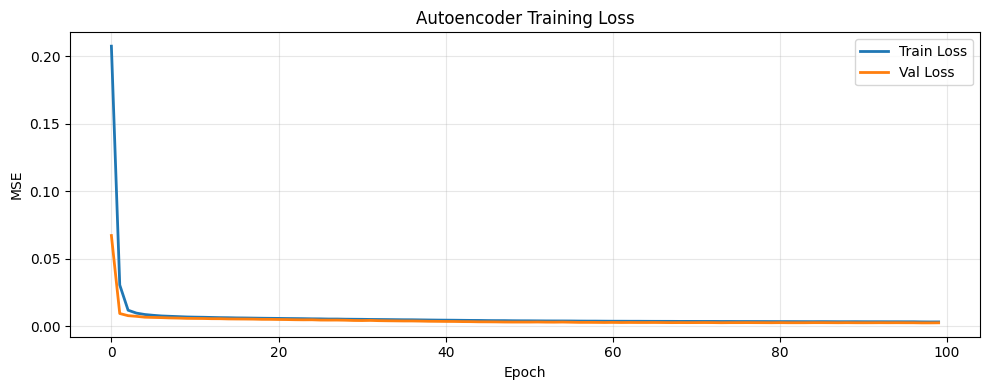

In [15]:
plt.figure(figsize=(10, 4))
plt.plot(ae_tr_loss,  label='Train Loss', linewidth=2)
plt.plot(ae_val_loss, label='Val Loss',   linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('MSE')
plt.title('Autoencoder Training Loss')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ae_loss.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
def recon_error(model, X):
    model.eval()
    with torch.no_grad():
        X_t     = torch.tensor(X, dtype=torch.float32).to(DEVICE)
        X_recon = model(X_t).cpu().numpy()
    return np.mean((X - X_recon) ** 2, axis=1)

train_recon  = recon_error(ae_model, X_train_scaled)
test_recon   = recon_error(ae_model, X_test_scaled)
ae_threshold = np.percentile(train_recon[normal_mask], 95)
ae_preds     = (test_recon > ae_threshold).astype(int)

print("=== Autoencoder Anomaly Detection ===")
print(f"Reconstruction Error Threshold: {ae_threshold:.6f}")
print(classification_report(y_test, ae_preds, target_names=['Normal', 'Failure']))
print(f"ROC-AUC: {roc_auc_score(y_test, test_recon):.4f}")

=== Autoencoder Anomaly Detection ===
Reconstruction Error Threshold: 0.004188
              precision    recall  f1-score   support

      Normal       0.65      0.29      0.40        75
     Failure       0.20      0.52      0.29        25

    accuracy                           0.35       100
   macro avg       0.42      0.41      0.34       100
weighted avg       0.53      0.35      0.37       100

ROC-AUC: 0.3152


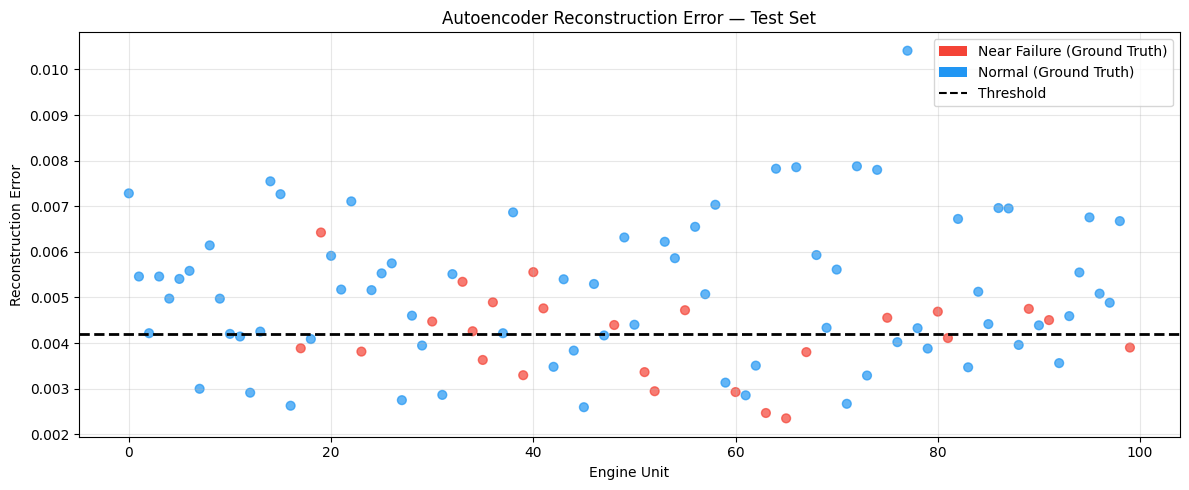

In [17]:
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#F44336' if y == 1 else '#2196F3' for y in y_test]
ax.scatter(range(len(test_recon)), test_recon, c=colors, s=40, alpha=0.7)
ax.axhline(ae_threshold, color='black', linestyle='--', linewidth=2,
           label=f'Threshold = {ae_threshold:.4f}')
legend_els = [
    mpatches.Patch(facecolor='#F44336', label='Near Failure (Ground Truth)'),
    mpatches.Patch(facecolor='#2196F3', label='Normal (Ground Truth)'),
    plt.Line2D([0],[0], color='black', linestyle='--', label='Threshold')
]
ax.legend(handles=legend_els)
ax.set_xlabel('Engine Unit'); ax.set_ylabel('Reconstruction Error')
ax.set_title('Autoencoder Reconstruction Error — Test Set')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ae_recon_errors.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.6 PyTorch LSTM for Failure Detection

In [18]:
SEQ_LEN = 30

def build_sequences(df, feat_cols, label_col, seq_len):
    Xs, ys = [], []
    for uid in df['unit_id'].unique():
        u  = df[df['unit_id'] == uid].sort_values('cycle')
        fa = u[feat_cols].values
        la = u[label_col].values
        for i in range(len(fa) - seq_len):
            Xs.append(fa[i:i+seq_len])
            ys.append(la[i+seq_len])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)


lstm_scaler = MinMaxScaler()
train_sc = train_df.copy()
train_sc[feature_cols] = lstm_scaler.fit_transform(train_df[feature_cols])

X_seq, y_seq = build_sequences(train_sc, feature_cols, 'failure_label', SEQ_LEN)
split = int(0.8 * len(X_seq))
X_tr, X_val = X_seq[:split], X_seq[split:]
y_tr, y_val = y_seq[:split], y_seq[split:]
print(f"LSTM sequences — train: {X_tr.shape}  val: {X_val.shape}")

LSTM sequences — train: (14104, 30, 46)  val: (3527, 30, 46)


In [19]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, num_layers=num_layers,
                            batch_first=True, dropout=dropout)
        self.head  = nn.Sequential(
            nn.Linear(hidden, 32), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 1), nn.Sigmoid()
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(1)


def train_sequence_model(model, X_tr, y_tr, X_val, y_val,
                          epochs=50, batch_size=512, lr=1e-3,
                          patience=10, loss_fn=None):
    if loss_fn is None:
        loss_fn = nn.BCELoss()

    loader = DataLoader(
        TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr)),
        batch_size=batch_size, shuffle=True
    )
    Xv = torch.tensor(X_val).to(DEVICE)
    yv = torch.tensor(y_val).to(DEVICE)

    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)

    best_val, best_state, no_imp = np.inf, None, 0
    tr_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        ep_loss = 0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            loss = loss_fn(model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
            ep_loss += loss.item() * len(xb)
        ep_loss /= len(X_tr)

        model.eval()
        with torch.no_grad():
            vl = loss_fn(model(Xv), yv).item()

        tr_losses.append(ep_loss); val_losses.append(vl)
        sched.step(vl)

        if vl < best_val:
            best_val, best_state, no_imp = vl, model.state_dict(), 0
        else:
            no_imp += 1
            if no_imp >= patience:
                print(f"Early stop at epoch {epoch+1}")
                break
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d} | train: {ep_loss:.4f} | val: {vl:.4f}")

    model.load_state_dict(best_state)
    return model, tr_losses, val_losses


lstm_cls = LSTMClassifier(input_size=X_tr.shape[2]).to(DEVICE)
lstm_cls, cls_tr_loss, cls_val_loss = train_sequence_model(
    lstm_cls, X_tr, y_tr, X_val, y_val, epochs=50, batch_size=512
)

Epoch  10 | train: 0.0879 | val: 0.1084
Epoch  20 | train: 0.0480 | val: 0.0822
Early stop at epoch 21


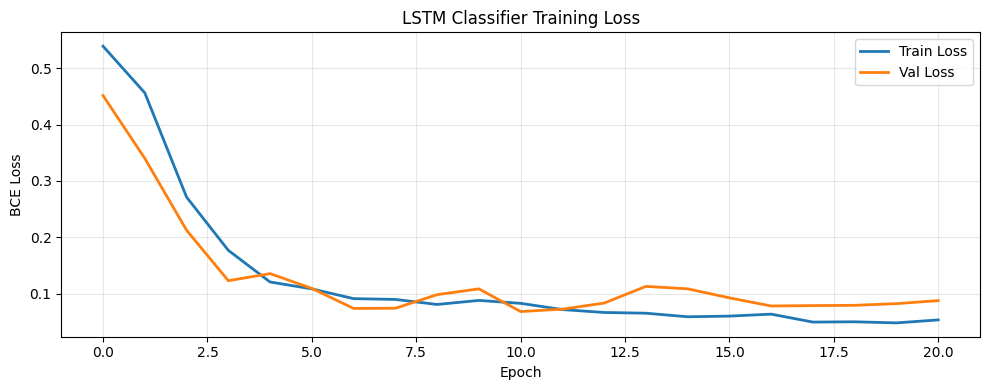

=== LSTM Classifier — Validation Set ===
              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98      2941
     Failure       0.89      0.90      0.90       586

    accuracy                           0.97      3527
   macro avg       0.94      0.94      0.94      3527
weighted avg       0.97      0.97      0.97      3527

ROC-AUC: 0.9931


In [20]:
plt.figure(figsize=(10, 4))
plt.plot(cls_tr_loss,  label='Train Loss', linewidth=2)
plt.plot(cls_val_loss, label='Val Loss',   linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('BCE Loss')
plt.title('LSTM Classifier Training Loss')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lstm_cls_loss.png', dpi=150, bbox_inches='tight')
plt.show()

lstm_cls.eval()
with torch.no_grad():
    val_probs = lstm_cls(torch.tensor(X_val).to(DEVICE)).cpu().numpy()
val_preds = (val_probs >= 0.5).astype(int)

print("=== LSTM Classifier — Validation Set ===")
print(classification_report(y_val, val_preds, target_names=['Normal', 'Failure']))
print(f"ROC-AUC: {roc_auc_score(y_val, val_probs):.4f}")

### 2.7 PyTorch LSTM for RUL Regression

In [21]:
MAX_RUL = 125

rul_scaler = MinMaxScaler()
train_rul  = train_df.copy()
train_rul['RUL_capped'] = train_rul['RUL'].clip(upper=MAX_RUL)
train_rul['RUL_norm']   = train_rul['RUL_capped'] / MAX_RUL
train_rul[feature_cols] = rul_scaler.fit_transform(train_rul[feature_cols])

X_rul, y_rul = build_sequences(train_rul, feature_cols, 'RUL_norm', SEQ_LEN)
split_r = int(0.8 * len(X_rul))
Xr_tr, Xr_val = X_rul[:split_r],  X_rul[split_r:]
yr_tr, yr_val = y_rul[:split_r],   y_rul[split_r:]
print(f"RUL sequences — train: {Xr_tr.shape}  val: {Xr_val.shape}")

RUL sequences — train: (14104, 30, 46)  val: (3527, 30, 46)


In [22]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, num_layers=num_layers,
                            batch_first=True, dropout=dropout)
        self.head  = nn.Sequential(
            nn.Linear(hidden, 32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 1), nn.Sigmoid()   # bounded output [0,1]
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(1)


lstm_reg = LSTMRegressor(input_size=Xr_tr.shape[2]).to(DEVICE)
lstm_reg, reg_tr_loss, reg_val_loss = train_sequence_model(
    lstm_reg, Xr_tr, yr_tr, Xr_val, yr_val,
    epochs=60, batch_size=512, lr=1e-3, patience=10,
    loss_fn=nn.MSELoss()
)

Epoch  10 | train: 0.0064 | val: 0.0125
Epoch  20 | train: 0.0026 | val: 0.0035
Epoch  30 | train: 0.0013 | val: 0.0018
Epoch  40 | train: 0.0015 | val: 0.0011
Epoch  50 | train: 0.0012 | val: 0.0013
Epoch  60 | train: 0.0010 | val: 0.0011


RUL Prediction — RMSE: 4.23 cycles | MAE: 2.51 cycles


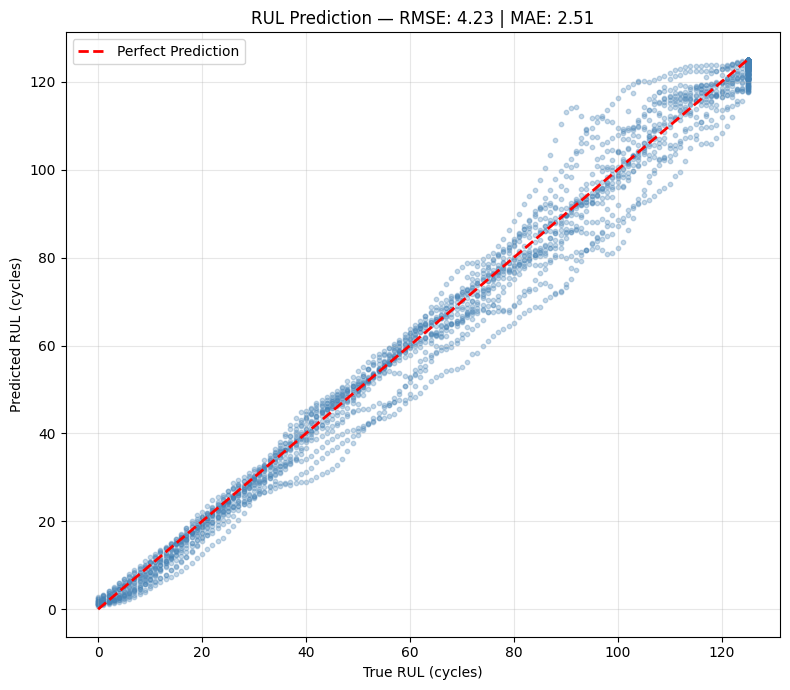

In [23]:
lstm_reg.eval()
with torch.no_grad():
    yr_pred_norm = lstm_reg(torch.tensor(Xr_val).to(DEVICE)).cpu().numpy()

yr_pred = yr_pred_norm * MAX_RUL
yr_true = yr_val * MAX_RUL
rmse    = np.sqrt(np.mean((yr_true - yr_pred) ** 2))
mae     = np.mean(np.abs(yr_true  - yr_pred))
print(f"RUL Prediction — RMSE: {rmse:.2f} cycles | MAE: {mae:.2f} cycles")

plt.figure(figsize=(8, 7))
plt.scatter(yr_true, yr_pred, alpha=0.3, s=10, color='steelblue')
plt.plot([0, MAX_RUL], [0, MAX_RUL], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('True RUL (cycles)'); plt.ylabel('Predicted RUL (cycles)')
plt.title(f'RUL Prediction — RMSE: {rmse:.2f} | MAE: {mae:.2f}')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rul_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.8 Comprehensive Model Evaluation

In [24]:
def false_alarm_rate(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp = cm[0, 0], cm[0, 1]
    return fp / (fp + tn + 1e-9)

models_eval = {
    'Z-Score Baseline': {'preds': baseline_preds, 'scores': test_zscores},
    'Isolation Forest':  {'preds': if_preds,       'scores': if_scores_test},
    'One-Class SVM':     {'preds': ocsvm_preds,    'scores': ocsvm_scores_test},
    'Autoencoder':       {'preds': ae_preds,        'scores': test_recon},
}

rows = []
for name, v in models_eval.items():
    auc = roc_auc_score(y_test, v['scores'])
    ap  = average_precision_score(y_test, v['scores'])
    f1  = f1_score(y_test, v['preds'])
    far = false_alarm_rate(y_test, v['preds'])
    rows.append({'Model': name, 'ROC-AUC': round(auc, 4),
                 'Avg Precision': round(ap, 4),
                 'F1-Score': round(f1, 4),
                 'False Alarm Rate': round(far, 4)})

results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))

           Model  ROC-AUC  Avg Precision  F1-Score  False Alarm Rate
Z-Score Baseline   0.9749         0.9383    0.8235            0.0667
Isolation Forest   0.9728         0.9369    0.8889            0.0667
   One-Class SVM   0.8213         0.7373    0.4894            0.6133
     Autoencoder   0.3152         0.1831    0.2857            0.7067


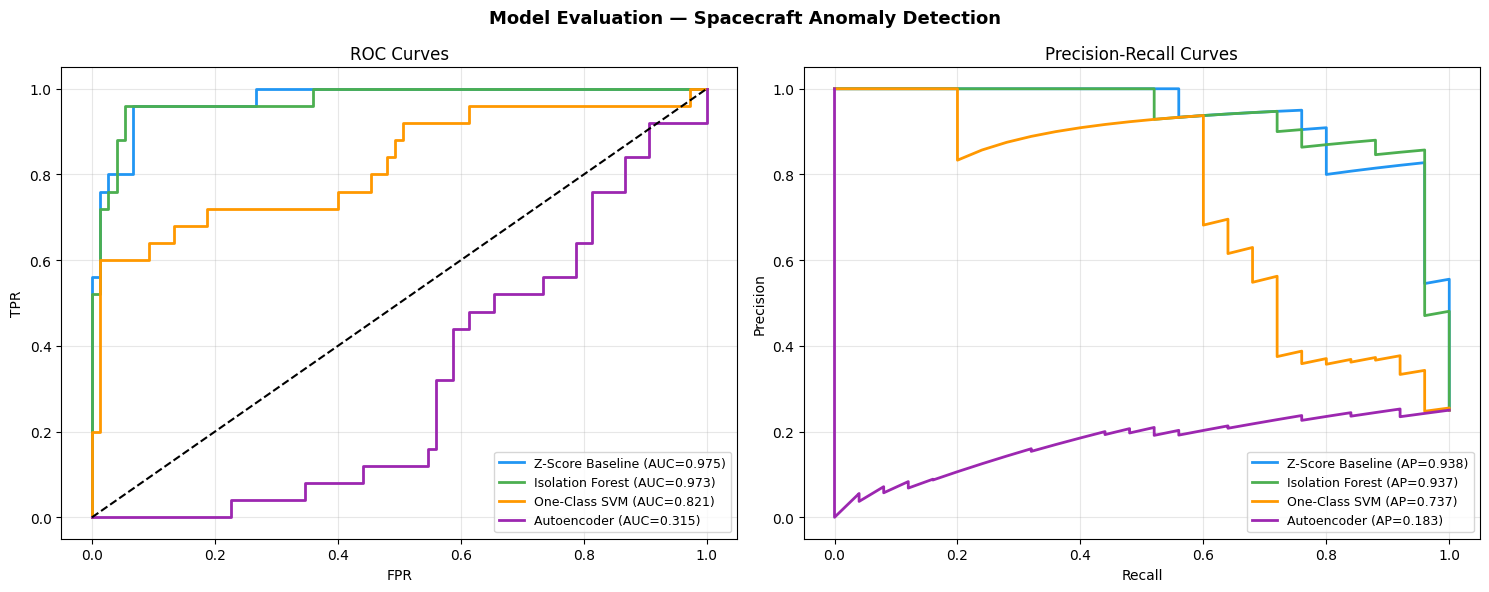

In [25]:
# ROC & Precision-Recall curves
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
pal = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for (name, v), c in zip(models_eval.items(), pal):
    fpr, tpr, _ = roc_curve(y_test, v['scores'])
    auc = roc_auc_score(y_test, v['scores'])
    axes[0].plot(fpr, tpr, color=c, linewidth=2, label=f'{name} (AUC={auc:.3f})')

    prec, rec, _ = precision_recall_curve(y_test, v['scores'])
    ap = average_precision_score(y_test, v['scores'])
    axes[1].plot(rec, prec, color=c, linewidth=2, label=f'{name} (AP={ap:.3f})')

axes[0].plot([0,1],[0,1],'k--')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curves'); axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves'); axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.suptitle('Model Evaluation — Spacecraft Anomaly Detection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

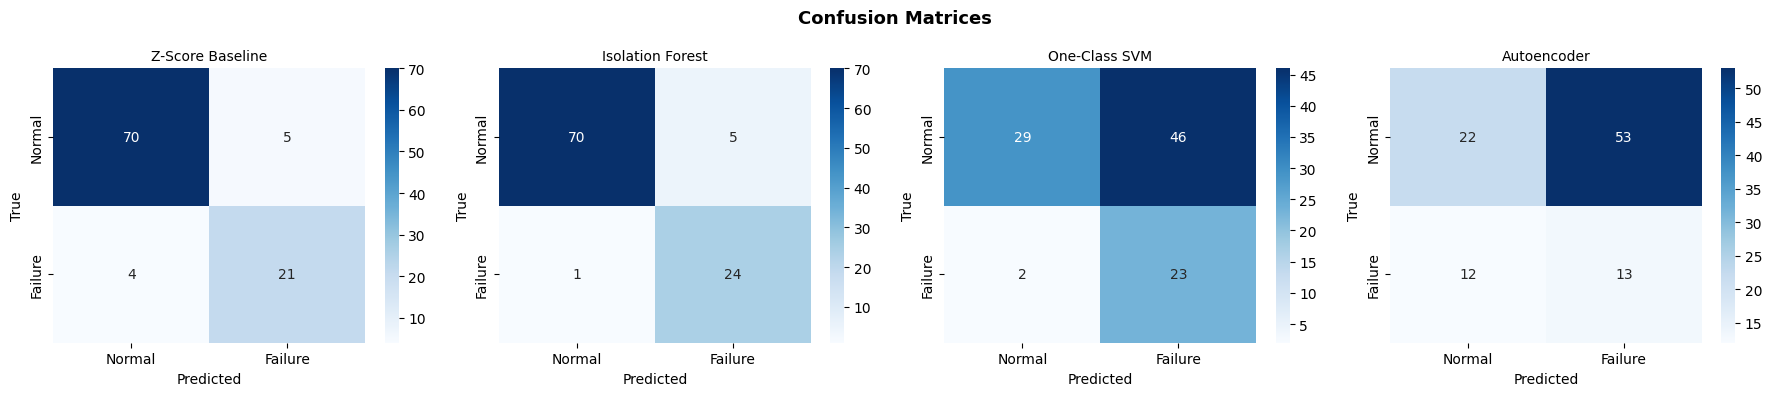

In [26]:
# Confusion matrices
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, v) in zip(axes, models_eval.items()):
    cm = confusion_matrix(y_test, v['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Failure'],
                yticklabels=['Normal', 'Failure'])
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Phase 3: Autonomous Decision Layer
### 3.1 Rule-Based Decision Logic

In [27]:
def rule_based_decision(anomaly_score, threshold, rul_estimate):
    is_anomaly = anomaly_score > threshold
    if   not is_anomaly and rul_estimate > 50: return 'NOMINAL — Continue Mission',              0
    elif not is_anomaly and rul_estimate > 20: return 'MONITOR — Increase Telemetry Rate',       1
    elif is_anomaly     and rul_estimate > 30: return 'CAUTION — Switch to Redundant Subsystem', 2
    elif is_anomaly     and rul_estimate > 10: return 'WARNING — Alert Ground Station',          3
    else:                                      return 'CRITICAL — Emergency Shutdown Protocol',  3

print(f"{'Engine':^8} {'AE Score':^12} {'Est. RUL':^10} {'Decision':<46} {'Sev':^5}")
print("-" * 85)
for i in range(min(10, len(y_test))):
    rul_i = int(yr_pred_norm[i % len(yr_pred_norm)] * MAX_RUL)
    action, sev = rule_based_decision(test_recon[i], ae_threshold, rul_i)
    print(f"{i+1:^8} {test_recon[i]:^12.5f} {rul_i:^10} {action:<46} {sev:^5}")

 Engine    AE Score    Est. RUL  Decision                                        Sev 
-------------------------------------------------------------------------------------
   1       0.00728        28     WARNING — Alert Ground Station                   3  
   2       0.00546        27     WARNING — Alert Ground Station                   3  
   3       0.00422        26     WARNING — Alert Ground Station                   3  
   4       0.00546        24     WARNING — Alert Ground Station                   3  
   5       0.00497        23     WARNING — Alert Ground Station                   3  
   6       0.00541        23     WARNING — Alert Ground Station                   3  
   7       0.00558        22     WARNING — Alert Ground Station                   3  
   8       0.00300        20     CRITICAL — Emergency Shutdown Protocol           3  
   9       0.00614        19     WARNING — Alert Ground Station                   3  
   10      0.00497        18     WARNING — Alert Groun

### 3.2 AI-Based Risk Scoring System

In [28]:
def compute_risk_score(ae_score, ae_thresh, if_score, rul_estimate,
                       max_rul=MAX_RUL, w=(0.40, 0.25, 0.35)):
    w_ae, w_if, w_rul = w
    ae_norm  = min(ae_score  / (3 * ae_thresh + 1e-9), 1.0)
    if_range = if_scores_test.max() - if_scores_test.min() + 1e-9
    if_norm  = min((if_score - if_scores_test.min()) / if_range, 1.0)
    rul_risk = max(0.0, 1.0 - rul_estimate / max_rul)
    return round(min((w_ae * ae_norm + w_if * if_norm + w_rul * rul_risk) * 100, 100.0), 2)

def risk_to_action(rs):
    if   rs < 20: return ('LOW',      'Nominal Operations')
    elif rs < 40: return ('MODERATE', 'Increase Monitoring Frequency')
    elif rs < 60: return ('ELEVATED', 'Switch to Redundant Subsystem')
    elif rs < 80: return ('HIGH',     'Alert Ground Station + Safe Mode')
    else:         return ('CRITICAL', 'Emergency Shutdown + Alert Earth')

risk_scores, risk_levels, actions = [], [], []
for i in range(len(y_test)):
    rul_i = int(yr_pred_norm[i % len(yr_pred_norm)] * MAX_RUL)
    rs    = compute_risk_score(test_recon[i], ae_threshold, if_scores_test[i], rul_i)
    level, action = risk_to_action(rs)
    risk_scores.append(rs); risk_levels.append(level); actions.append(action)

risk_scores = np.array(risk_scores)
print("Risk Level Distribution:")
print(pd.Series(risk_levels).value_counts())

Risk Level Distribution:
MODERATE    49
ELEVATED    26
LOW         21
HIGH         4
Name: count, dtype: int64


### 3.3 Decision Confidence Estimation

In [29]:
if_pct95 = np.percentile(if_scores_test, 95)

def decision_confidence(ae_score, ae_thresh, if_score, if_thresh):
    ae_anom = ae_score > ae_thresh
    if_anom = if_score > if_thresh
    agree   = ae_anom == if_anom
    ae_marg = abs(ae_score - ae_thresh) / (ae_thresh + 1e-9)
    if_marg = abs(if_score - if_thresh) / (if_thresh + 1e-9)
    conf    = min((ae_marg + if_marg) / 2.0 * 100, 90) + (10 if agree else -20)
    conf    = max(10, min(conf, 99))
    return round(conf, 1), 'HIGH' if conf >= 75 else ('MEDIUM' if conf >= 50 else 'LOW')

conf_scores, conf_levels = [], []
for i in range(len(y_test)):
    c, l = decision_confidence(test_recon[i], ae_threshold, if_scores_test[i], if_pct95)
    conf_scores.append(c); conf_levels.append(l)

print("Decision Confidence Levels:")
print(pd.Series(conf_levels).value_counts())

print(f"\n{'Engine':^8} {'Risk':^8} {'Level':^12} {'Confidence':^12} {'Conf Level':^12}")
print("-" * 58)
for i in range(min(10, len(y_test))):
    print(f"{i+1:^8} {risk_scores[i]:^8.1f} {risk_levels[i]:^12} "
          f"{conf_scores[i]:^12.1f} {conf_levels[i]:^12}")

Decision Confidence Levels:
LOW       99
MEDIUM     1
Name: count, dtype: int64

 Engine    Risk      Level      Confidence   Conf Level 
----------------------------------------------------------
   1       56.7     ELEVATED       29.6         LOW     
   2       49.6     ELEVATED       10.0         LOW     
   3       49.0     ELEVATED       10.0         LOW     
   4       52.1     ELEVATED       10.0         LOW     
   5       50.1     ELEVATED       10.0         LOW     
   6       50.7     ELEVATED       10.0         LOW     
   7       52.1     ELEVATED       10.0         LOW     
   8       42.2     ELEVATED       39.3         LOW     
   9       54.1     ELEVATED       17.1         LOW     
   10      48.3     ELEVATED       10.0         LOW     


---
## Phase 4: Visualization Dashboard

In [30]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

# ================================================================
# DASHBOARD 1 — Mission Control Overview (Plotly)
# ================================================================
n          = len(y_test)
engine_ids = list(range(1, n + 1))

# FIX 1: Add 'specs' to define the subplot types. 
# We set row 2, col 1 to "domain" to support the Pie chart.
fig = make_subplots(
    rows=2, cols=2,
    specs=[[{"type": "xy"}, {"type": "xy"}],
           [{"type": "domain"}, {"type": "xy"}]],
    subplot_titles=['Risk Score per Engine', 'Anomaly Score vs Threshold',
                    'Risk Level Distribution', 'Decision Confidence']
)

# 1. Risk Score Bar Chart (Row 1, Col 1)
bar_colors = ['#F44336' if rs >= 60 else '#FFC107' if rs >= 40 else '#4CAF50'
              for rs in risk_scores]
fig.add_trace(go.Bar(x=engine_ids, y=risk_scores, marker_color=bar_colors,
                     name='Risk Score', showlegend=False), row=1, col=1)
fig.add_hline(y=60, line_dash='dash', line_color='red',
              annotation_text='Alert Threshold', row=1, col=1)

# 2. Anomaly Score Scatter Plot (Row 1, Col 2)
fig.add_trace(go.Scatter(
    x=engine_ids, y=test_recon, mode='markers',
    marker=dict(color=['red' if y == 1 else 'deepskyblue' for y in y_test],
                size=7, opacity=0.7),
    name='AE Score'
), row=1, col=2)
fig.add_hline(y=ae_threshold, line_dash='dash', line_color='black',
              annotation_text='Threshold', row=1, col=2)

# 3. Risk Levels Pie Chart (Row 2, Col 1)
lv = pd.Series(risk_levels).value_counts()
# FIX 2: Use marker=dict(colors=[...]) instead of marker_colors
fig.add_trace(go.Pie(labels=lv.index, values=lv.values,
                     marker=dict(colors=['#4CAF50','#8BC34A','#FFC107','#FF5722','#F44336']),
                     name='Risk Levels'), row=2, col=1)

# 4. Decision Confidence Histogram (Row 2, Col 2)
fig.add_trace(go.Histogram(x=conf_scores, nbinsx=20, marker_color='steelblue',
                            showlegend=False), row=2, col=2)

# Layout adjustments
fig.update_layout(
    title_text='🛸 Deep Space Mission — Autonomous Decision Support Dashboard',
    title_font_size=15, height=700,
    paper_bgcolor='#0a0a1a', plot_bgcolor='#0d1117',
    font=dict(color='white')
)
fig.update_xaxes(gridcolor='#333', zeroline=False)
fig.update_yaxes(gridcolor='#333', zeroline=False)

fig.show()
fig.write_html('mission_control_dashboard.html')
print("Dashboard saved -> mission_control_dashboard.html")

Dashboard saved -> mission_control_dashboard.html


In [31]:
# ================================================================
# DASHBOARD 2 — Live Telemetry for Selected Engine
# ================================================================
SELECTED_UNIT = 5
unit_data  = train_df[train_df['unit_id'] == SELECTED_UNIT].sort_values('cycle')
fail_cycle = unit_data['cycle'].max() - FAILURE_THRESHOLD

fig2 = make_subplots(
    rows=3, cols=1, shared_xaxes=True,
    subplot_titles=[f'Sensor 7 — Engine {SELECTED_UNIT}',
                    f'Sensor 12 — Engine {SELECTED_UNIT}',
                    f'RUL — Engine {SELECTED_UNIT}'],
    vertical_spacing=0.08
)

for row, sensor in enumerate(['sensor_7', 'sensor_12'], start=1):
    fig2.add_trace(go.Scatter(x=unit_data['cycle'], y=unit_data[sensor],
                              mode='lines', line=dict(color='#00BCD4', width=1.5),
                              name=sensor), row=row, col=1)
    fig2.add_vrect(x0=fail_cycle, x1=unit_data['cycle'].max(),
                   fillcolor='red', opacity=0.15, row=row, col=1)

fig2.add_trace(go.Scatter(x=unit_data['cycle'], y=unit_data['RUL'],
                           mode='lines', fill='tozeroy',
                           line=dict(color='#FF9800'), name='RUL'), row=3, col=1)
fig2.add_hline(y=FAILURE_THRESHOLD, line_dash='dash', line_color='red',
               annotation_text='Failure Zone', row=3, col=1)

fig2.update_layout(
    title_text=f'🔭 Live Telemetry — Engine Unit {SELECTED_UNIT}',
    height=650, paper_bgcolor='#0a0a1a',
    plot_bgcolor='#0d1117', font=dict(color='white')
)
fig2.update_xaxes(gridcolor='#333', title_text='Cycle', row=3, col=1)
fig2.update_yaxes(gridcolor='#333')
fig2.show()
fig2.write_html('live_telemetry_dashboard.html')
print("Telemetry dashboard saved -> live_telemetry_dashboard.html")

Telemetry dashboard saved -> live_telemetry_dashboard.html


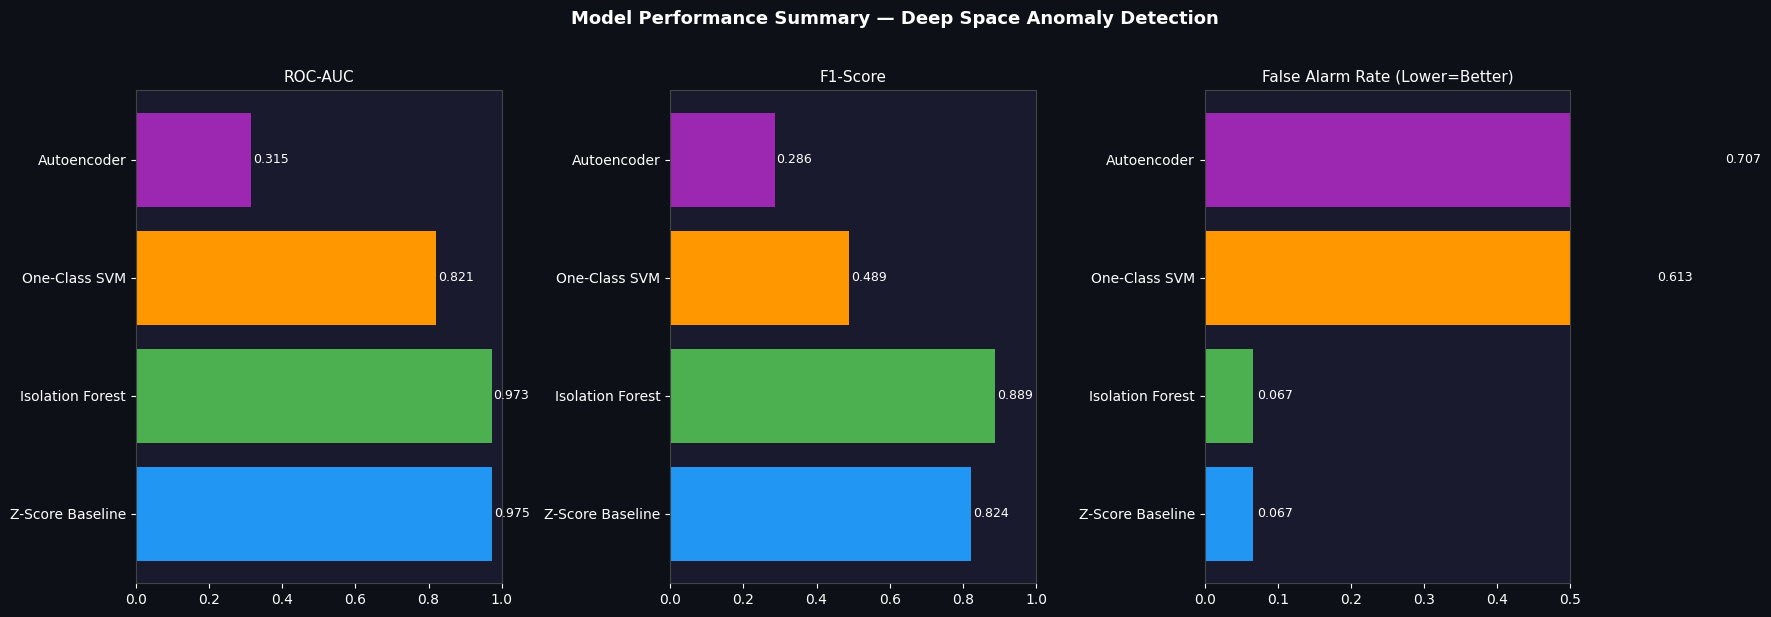

All visualizations complete!


In [32]:
# ================================================================
# DASHBOARD 3 — Model Comparison Summary (Matplotlib)
# ================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#0d1117')
for ax in axes:
    ax.set_facecolor('#1a1a2e')
    for spine in ax.spines.values(): spine.set_color('#444')
    ax.tick_params(colors='white')

names = results_df['Model'].tolist()
pal   = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

metrics = [('ROC-AUC', 1.0), ('F1-Score', 1.0), ('False Alarm Rate', 0.5)]
for ax, (metric, xlim) in zip(axes, metrics):
    vals = results_df[metric].tolist()
    ax.barh(names, vals, color=pal)
    ax.set_xlim(0, xlim)
    label = metric + (' (Lower=Better)' if metric == 'False Alarm Rate' else '')
    ax.set_title(label, color='white', fontsize=11)
    ax.tick_params(colors='white')
    for i, v in enumerate(vals):
        ax.text(v + 0.005, i, f'{v:.3f}', va='center', color='white', fontsize=9)

plt.suptitle('Model Performance Summary — Deep Space Anomaly Detection',
             color='white', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_summary.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("All visualizations complete!")

In [33]:
# ================================================================
# FINAL SUMMARY
# ================================================================
print("=" * 65)
print("  AI-BASED DEEP SPACE MISSION ANOMALY DETECTION — SUMMARY")
print("=" * 65)
print(f"  Dataset          : NASA CMAPSS FD001")
print(f"  Training engines : {train_df['unit_id'].nunique()}")
print(f"  Test engines     : {test_df['unit_id'].nunique()}")
print(f"  Feature count    : {len(feature_cols)}")
print(f"  Failure threshold: RUL <= {FAILURE_THRESHOLD} cycles")
print(f"  Device used      : {DEVICE}")
print("-" * 65)
print("  ANOMALY DETECTION RESULTS")
print("-" * 65)
print(results_df.to_string(index=False))
print("-" * 65)
print("  RUL PREDICTION (LSTM Regressor)")
print(f"    RMSE : {rmse:.2f} cycles")
print(f"    MAE  : {mae:.2f} cycles")
print("-" * 65)
print("  AUTONOMOUS DECISION SYSTEM")
for lvl, cnt in pd.Series(risk_levels).value_counts().items():
    print(f"    {lvl:<12}: {cnt} engines ({cnt/n*100:.1f}%)")
print("=" * 65)

  AI-BASED DEEP SPACE MISSION ANOMALY DETECTION — SUMMARY
  Dataset          : NASA CMAPSS FD001
  Training engines : 100
  Test engines     : 100
  Feature count    : 46
  Failure threshold: RUL <= 30 cycles
  Device used      : cpu
-----------------------------------------------------------------
  ANOMALY DETECTION RESULTS
-----------------------------------------------------------------
           Model  ROC-AUC  Avg Precision  F1-Score  False Alarm Rate
Z-Score Baseline   0.9749         0.9383    0.8235            0.0667
Isolation Forest   0.9728         0.9369    0.8889            0.0667
   One-Class SVM   0.8213         0.7373    0.4894            0.6133
     Autoencoder   0.3152         0.1831    0.2857            0.7067
-----------------------------------------------------------------
  RUL PREDICTION (LSTM Regressor)
    RMSE : 4.23 cycles
    MAE  : 2.51 cycles
-----------------------------------------------------------------
  AUTONOMOUS DECISION SYSTEM
    MODERATE    : 49